In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import copy

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from imports import *
from config import dir_config, ephys_config
from src.utils import dpca_utils, ephys_utils

In [3]:
compiled_dir  = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

## Load data

Data loading stays in the notebook. The utils start after you have
`session_metadata`, `neuron_metadata`, `ephys`, and the trial-info dicts.

In [4]:

session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]

session_metadata = pd.read_csv(Path(processed_dir, "sessions_metadata.csv"))
session_metadata = session_metadata[~session_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

neuron_metadata = pd.read_csv(Path(processed_dir, "neuron_metadata.csv"))
neuron_metadata = neuron_metadata[~neuron_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)

with open(Path(processed_dir, "glm_hmm_models", "glm_hmm_masked_final.pkl"), "rb") as f:
    glm_hmm = pickle.load(f)
glm_hmm_original = copy.deepcopy(glm_hmm)

try:
    if ephys_data is not None:
        print("Ephys data already loaded.")
except NameError:
    with open(Path(processed_dir, "ephys_neuron_wise.pkl"), "rb") as f:
        ephys_data = pickle.load(f)

toRF_sessions  = session_metadata.session_id[session_metadata.prior_direction == "toRF"]
awayRF_sessions = session_metadata.session_id[session_metadata.prior_direction == "awayRF"]

alignments = list(ephys_config["alignment_settings_GP"].keys())  # ['baseline','visual','cue','response']


In [5]:
def prepare_trial_info(glm_hmm):
    data = glm_hmm["data"]
    # also flips sign for awayRF sessions in-place on glm_hmm["data"]
    biased_state_trial_info, unbiased_state_trial_info, state_occupancy = \
        dpca_utils.extract_hmm_state_trial_info(session_metadata, glm_hmm_original, data,
                                            compiled_dir=compiled_dir)

    assert biased_state_trial_info.keys() == unbiased_state_trial_info.keys(), \
        f"Session key mismatch: {biased_state_trial_info.keys() ^ unbiased_state_trial_info.keys()}"

    frames = []
    for session_id in biased_state_trial_info:
        biased_df   = biased_state_trial_info[session_id].copy()
        unbiased_df = unbiased_state_trial_info[session_id].copy()
        biased_df["hmm_state"]   = 1
        unbiased_df["hmm_state"] = 0
        session_df = pd.concat([biased_df, unbiased_df], ignore_index=True)
        session_df = session_df[session_df.reaction_time.notna()]

        session_trial_data = pd.read_csv(
            compiled_dir / session_id / f"{session_id}_trial_cleaned.csv", index_col=None
        )
        session_trial_data = session_trial_data.rename(columns={"trial_number": "trial_num"})
        session_df = pd.merge(session_df, session_trial_data[["trial_num", "target", "outcome"]], on="trial_num", how="left")

        session_df = session_df.sort_values("trial_num").reset_index(drop=True)
        session_df.insert(0, "session_id", session_id)
        frames.append(session_df)

    trial_info = pd.concat(frames, ignore_index=True)
    trial_info = trial_info[["session_id", "trial_num", "stimulus", "hmm_state", "prob_toRF", "target", "choices", "reaction_time", "outcome"]].rename(columns={
        "stimulus": "signed_coherence",
        "prob_toRF": "prior_block",
        "choices": "choice",
    })
    trial_info["prior_block"] = (trial_info["prior_block"] != 50).astype(int)
    # trial_info["coh_sign"] = np.sign(trial_info["signed_coherence"]).astype(int)
    return trial_info

In [6]:
def get_trial_num_from_glm_hmm(trial_data, coherence=None, choice=None, target=None, outcome=None):
    trial_mask = np.ones(len(trial_data), dtype=bool)
    if coherence is not None:
        trial_mask = trial_mask & (trial_data.signed_coherence == coherence)
    if choice is not None:
        trial_mask = trial_mask & (trial_data.choice == choice)
    if target is not None:
        trial_mask = trial_mask & (trial_data.target == target)
    if outcome is not None:
        trial_mask = trial_mask & (trial_data.outcome == outcome)
    selected_trials = trial_data[trial_mask]
    return np.array(selected_trials.trial_num.values.reshape(-1, 1))

In [7]:
def build_sampling_plan(trial_info, label_col, match_cols, n_per_cell=50, rng=None):
    """
    For each condition cell in the INTERSECTION of cells across all sessions,
    independently sample n_per_cell trials with replacement from every session.

    Returns
    -------
    plan : {session_id: {cell_key: trial_nums (n_per_cell,)}}
    pseudo_y : (n_cells * n_per_cell,)  — label for each pseudo-trial
    valid_sessions : list of all sessions (all have the intersected cells)
    """
    rng = np.random.default_rng(rng)
    group_cols = [label_col] + match_cols

    # Intersect condition cells across all sessions so every session qualifies
    session_cell_sets = []
    for sid in trial_info.session_id.unique():
        sess = trial_info[trial_info.session_id == sid]
        session_cell_sets.append(set(map(tuple, sess[group_cols].values)))

    all_cells = sorted(session_cell_sets[0].intersection(*session_cell_sets[1:]))

    if not all_cells:
        raise ValueError(
            f"No condition cells are shared across all sessions for "
            f"label='{label_col}', match={match_cols}. "
            f"Consider using fewer or coarser match columns."
        )

    n_classes = len(set(c[0] for c in all_cells))
    if n_classes < 2:
        raise ValueError(
            f"Only one class found for '{label_col}' in shared cells: "
            f"{set(c[0] for c in all_cells)}"
        )

    valid_sessions = list(trial_info.session_id.unique())
    print(f"{len(valid_sessions)} sessions valid, "
        f"{len(all_cells)} shared condition cells x {n_per_cell} trials "
        f"= {len(all_cells) * n_per_cell} pseudo-trials")

    plan = {}
    for sid in valid_sessions:
        sess = trial_info[trial_info.session_id == sid]
        plan[sid] = {}
        for cell in all_cells:
            mask = (sess[group_cols] == pd.Series(dict(zip(group_cols, cell)))).all(axis=1)
            cell_trials = sess.trial_num.values[mask.values]
            plan[sid][cell] = rng.choice(cell_trials, size=n_per_cell, replace=True)

    pseudo_y = np.array([cell[0] for cell in all_cells for _ in range(n_per_cell)])
    return plan, pseudo_y, valid_sessions

In [8]:
def extract_pseudo_X(plan, valid_sessions, alignment, t_start_idx, t_end_idx):
    """
    Build the pseudo-population spike-count matrix for one 50ms time bin.

    Returns
    -------
    pseudo_X : (n_total_neurons, n_pseudo_trials)
    """
    rows = []
    for sid in valid_sessions:
        neuron_ids = neuron_metadata.neuron_id[neuron_metadata.session_id == sid].values
        session_counts = {nid: [] for nid in neuron_ids}
        for trial_nums in plan[sid].values():
            for nid in neuron_ids:
                counts = ephys_utils.get_windowed_spike_count(
                    ephys_data[alignment][nid], trial_nums, t_start_idx, t_end_idx)
                session_counts[nid].extend(counts.tolist())
        for nid in neuron_ids:
            rows.append(session_counts[nid])
    return np.array(rows)  # (n_total_neurons, n_pseudo_trials)

In [9]:
def decode_timecourse(trial_info, label_col, match_cols, alignment,
                      bin_size=50, n_per_cell=50, n_repeats=10,
                      return_weights=False, n_permutations=0):
    """
    Time-resolved decoding accuracy for one variable × alignment combination.

    Parameters
    ----------
    trial_info      : DataFrame — caller decides which rows to pass (e.g. correct-only)
    label_col       : column to decode
    match_cols      : columns to condition-match on (nuisance variables to balance)
    alignment       : one of the keys in ephys_config alignment_settings_GP
    bin_size        : width of each sliding window in ms
    n_per_cell      : bootstrap trials sampled per condition cell per repeat
    n_repeats       : number of independent sampling + decoding repeats (real labels)
    return_weights  : if True, also return mean weight matrix and ordered neuron IDs
    n_permutations  : if >0, compute null distribution by shuffling labels this many times;
                      X is extracted once per bin and labels are reshuffled per permutation

    Returns (n_permutations == 0)
    --------------------------------
    times, mean_acc, sem_acc
    times, mean_acc, sem_acc, mean_weights, neuron_ids  (if return_weights)

    Returns (n_permutations > 0)
    --------------------------------
    times, mean_acc, sem_acc, null_accs  — null_accs: (n_permutations, n_bins)
    times, mean_acc, sem_acc, null_accs, mean_weights, neuron_ids  (if return_weights)
    """
    cfg = ephys_config["alignment_settings_GP"][alignment]
    epoch_start, epoch_end = cfg["start_time_ms"], cfg["end_time_ms"]

    if alignment == "cue":
        min_rt = int(trial_info.loc[trial_info["outcome"] == 1, "reaction_time"].min())
        epoch_end = min(epoch_end, min_rt)
        print(f"Cue epoch trimmed to {epoch_end}ms (min RT={min_rt}ms). "
              f"150-200ms bin {'included' if epoch_end >= 200 else 'NOT included'}.")

    elif alignment == "response":
        min_rt = int(trial_info.loc[trial_info["outcome"] == 1, "reaction_time"].min())
        epoch_start = max(epoch_start, -min_rt)
        print(f"Response epoch trimmed to {epoch_start}ms (min RT={min_rt}ms). "
              f"150-200ms bin {'included' if epoch_start < -200 else 'NOT included'}.")

    bin_starts  = list(range(epoch_start, epoch_end - bin_size + 1, bin_size))
    bin_centres = [b + bin_size // 2 for b in bin_starts]

    # ── Real decoding ────────────────────────────────────────────────────────────
    repeat_accs    = []
    repeat_weights = []
    neuron_ids     = None

    for _ in range(n_repeats):
        rng = np.random.default_rng()
        plan, pseudo_y, valid_sessions = build_sampling_plan(
            trial_info, label_col, match_cols, n_per_cell=n_per_cell, rng=rng)
        pseudo_y = pseudo_y.astype(str)

        if neuron_ids is None:
            neuron_ids = [
                nid
                for sid in valid_sessions
                for nid in neuron_metadata.neuron_id[neuron_metadata.session_id == sid].values
            ]

        bin_accs    = []
        bin_weights = []
        for b in bin_starts:
            t0 = b - epoch_start
            t1 = t0 + bin_size
            X = extract_pseudo_X(plan, valid_sessions, alignment, t0, t1)
            X_tr, X_te, y_tr, y_te = train_test_split(
                X.T, pseudo_y, test_size=0.2, stratify=pseudo_y,
                random_state=rng.integers(int(1e6)))
            clf = LogisticRegression(max_iter=300, C=1.0)
            clf.fit(X_tr, y_tr)
            bin_accs.append(clf.score(X_te, y_te))
            if return_weights:
                bin_weights.append(clf.coef_.squeeze())

        repeat_accs.append(bin_accs)
        if return_weights:
            repeat_weights.append(bin_weights)

    times    = np.array(bin_centres)
    mean_acc = np.mean(repeat_accs, axis=0)
    sem_acc  = np.std(repeat_accs, axis=0) / np.sqrt(n_repeats)
    mean_weights = np.mean(repeat_weights, axis=0) if return_weights else None

    # ── Null distribution (label scrambling) ────────────────────────────────────
    if n_permutations > 0:
        rng_null = np.random.default_rng()
        plan_null, y_null, sess_null = build_sampling_plan(
            trial_info, label_col, match_cols, n_per_cell=n_per_cell, rng=rng_null)
        y_null = y_null.astype(str)

        # Extract X once per bin; shuffle labels n_permutations times per bin
        null_accs = np.zeros((n_permutations, len(bin_starts)))
        for bi, b in enumerate(bin_starts):
            t0 = b - epoch_start
            t1 = t0 + bin_size
            X_null = extract_pseudo_X(plan_null, sess_null, alignment, t0, t1)
            for pi in range(n_permutations):
                shuffled_y = rng_null.permutation(y_null)
                X_tr, X_te, y_tr, y_te = train_test_split(
                    X_null.T, shuffled_y, test_size=0.2, stratify=shuffled_y,
                    random_state=rng_null.integers(int(1e6)))
                clf = LogisticRegression(max_iter=300, C=1.0)
                clf.fit(X_tr, y_tr)
                null_accs[pi, bi] = clf.score(X_te, y_te)

        if return_weights:
            return times, mean_acc, sem_acc, null_accs, mean_weights, neuron_ids
        return times, mean_acc, sem_acc, null_accs

    if return_weights:
        return times, mean_acc, sem_acc, mean_weights, neuron_ids
    return times, mean_acc, sem_acc

43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials

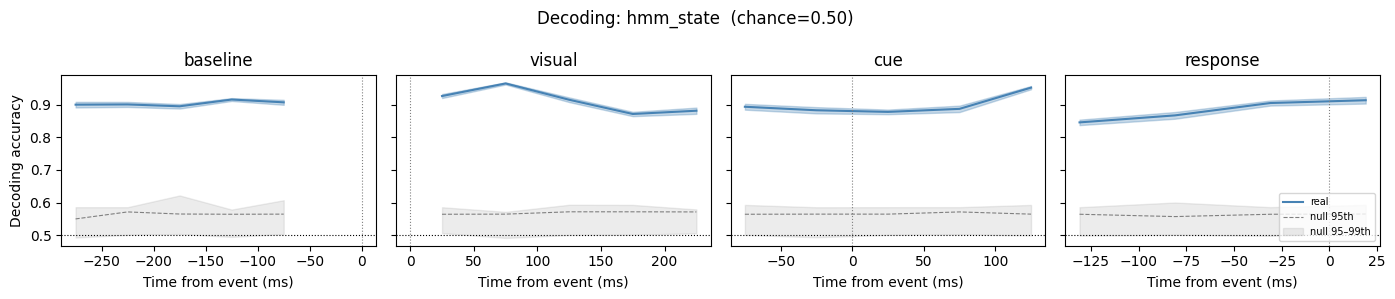

43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials
43 sessions valid, 14 shared condition cells x 50 trials = 700 pseudo-trials

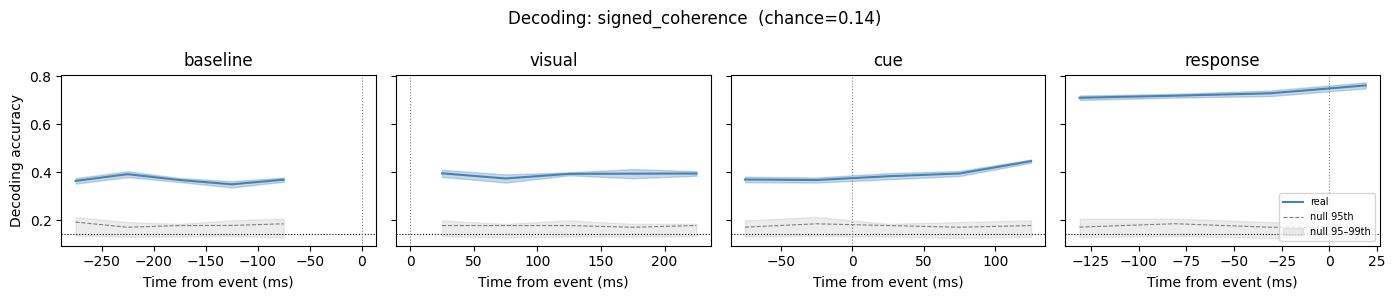

43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 

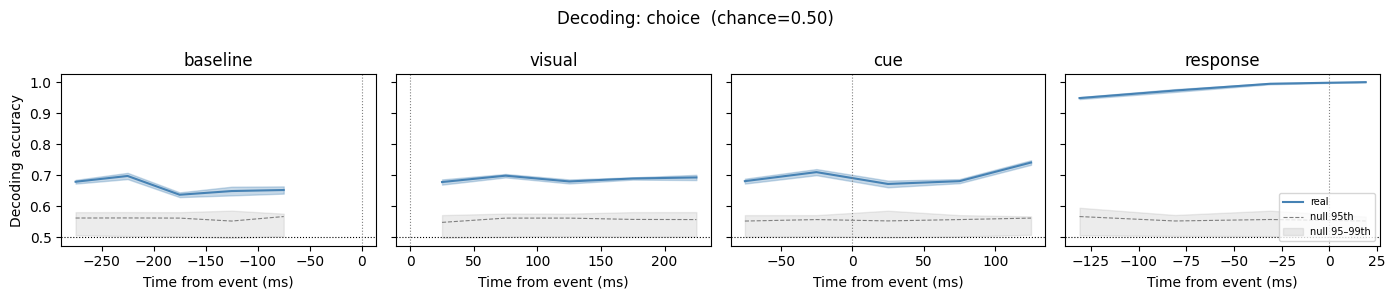

In [10]:
trial_info = prepare_trial_info(glm_hmm)
correct = trial_info["outcome"] == 1

# label_col → (match_cols, df_subset)
decode_cfg = {
    "hmm_state":        (["signed_coherence"],               trial_info[correct]),
    "signed_coherence": (["hmm_state"],                      trial_info[correct]),
    "choice":           (["signed_coherence", "hmm_state"],  trial_info),  # all trials
}

N_PERMUTATIONS = 100  # number of label-shuffle permutations for null distribution

for label_col, (match_cols, df_subset) in decode_cfg.items():
    chance = 1 / df_subset[label_col].nunique()
    fig, axes = plt.subplots(1, len(alignments), figsize=(14, 3), sharey=True)
    for ax, alignment in zip(axes, alignments):
        times, acc, sem, null_accs = decode_timecourse(
            df_subset, label_col, match_cols, alignment,
            n_permutations=N_PERMUTATIONS)

        null_mean = null_accs.mean(axis=0)
        null_95   = np.percentile(null_accs, 95, axis=0)
        null_99   = np.percentile(null_accs, 99, axis=0)

        # Real decoding
        ax.plot(times, acc, color="steelblue", label="real")
        ax.fill_between(times, acc - sem, acc + sem, alpha=0.3, color="steelblue")

        # Null distribution
        ax.plot(times, null_95, color="gray", linestyle="--", linewidth=0.8, label="null 95th")
        ax.fill_between(times, null_mean, null_99, alpha=0.15, color="gray", label="null 95–99th")

        ax.axhline(chance, color="k", linestyle=":", linewidth=0.8)
        ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(alignment)
        ax.set_xlabel("Time from event (ms)")
    axes[0].set_ylabel("Decoding accuracy")
    axes[-1].legend(fontsize=7, loc="lower right")
    fig.suptitle(f"Decoding: {label_col}  (chance={chance:.2f})")
    plt.tight_layout()
    plt.show()

Response epoch trimmed to -156ms (min RT=156ms). 150-200ms bin NOT included.
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials


43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials
43 sessions valid, 21 shared condition cells x 50 trials = 1050 pseudo-trials


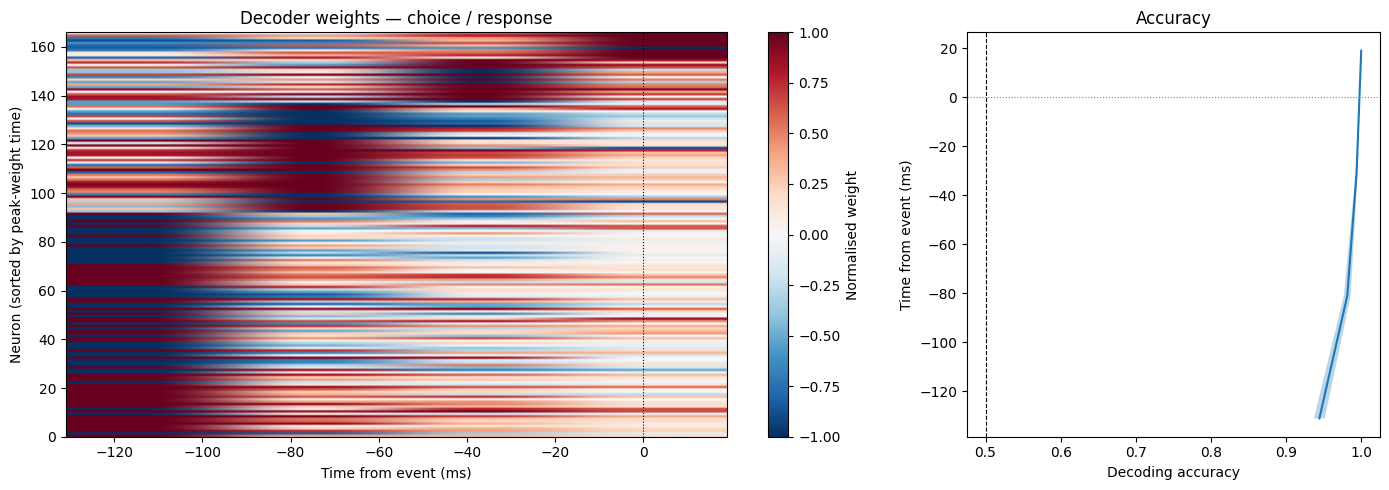

Weight matrix shape: (4, 166)  (n_bins=4, n_neurons=166)


In [11]:
# --- Weight timecourse ---
# Run for one label × alignment of interest; adjust as needed.
label_col  = "choice"
match_cols = ["signed_coherence", "hmm_state"]
alignment  = "response"
df_subset  = trial_info   # all trials for choice decoding

times, acc, sem, W, neuron_ids = decode_timecourse(
    df_subset, label_col, match_cols, alignment, return_weights=True)

# W: (n_bins, n_neurons) — sort neurons by peak-weight time
peak_bin = np.argmax(np.abs(W), axis=0)          # (n_neurons,)
sort_idx = np.argsort(peak_bin)
W_sorted = W[:, sort_idx]                        # (n_bins, n_neurons)

# Normalize each neuron to its max |weight| for display clarity
W_norm = W_sorted / (np.abs(W_sorted).max(axis=0, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 1]})

# Heatmap: neurons × time
im = axes[0].imshow(
    W_norm.T, aspect="auto", origin="lower",
    extent=[times[0], times[-1], 0, W_norm.shape[1]],
    cmap="RdBu_r", vmin=-1, vmax=1,
)
axes[0].axvline(0, color="k", linestyle=":", linewidth=0.8)
axes[0].set_xlabel("Time from event (ms)")
axes[0].set_ylabel("Neuron (sorted by peak-weight time)")
axes[0].set_title(f"Decoder weights — {label_col} / {alignment}")
plt.colorbar(im, ax=axes[0], label="Normalised weight")

# Accuracy alongside
axes[1].plot(acc, times)
axes[1].fill_betweenx(times, acc - sem, acc + sem, alpha=0.3)
axes[1].axhline(0, color="gray", linestyle=":", linewidth=0.8)
axes[1].axvline(0.5, color="k", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Decoding accuracy")
axes[1].set_ylabel("Time from event (ms)")
axes[1].set_title("Accuracy")

plt.tight_layout()
plt.show()

print(f"Weight matrix shape: {W.shape}  (n_bins={W.shape[0]}, n_neurons={W.shape[1]})")